# Egyptian NID localization (YOLO)

Trains a YOLO detector on `Thndr-National-Card.v4-v4.yolov8` to find the **ID number field** on the card, then crops those boxes for digit OCR.

**Kernel:** select `.venv` before you run anything.

Cursor: `Select Kernel` → `Python Environments` → `.venv` (`Python 3.12`).

If the venv is missing:

```powershell
python -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install -U pip
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
pip install -r requirements.txt
```

Digit reading is a separate step: [`train_nid_digits.ipynb`](train_nid_digits.ipynb) + [`yolo+ocr/run_pipeline.py`](yolo+ocr/run_pipeline.py).


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "Thndr-National-Card.v4-v4.yolov8").exists():
    raise FileNotFoundError(f"Dataset folder not found in {ROOT}")

if ".venv" not in Path(sys.prefix).resolve().parts:
    raise RuntimeError(
        f"This kernel is {sys.executable}\n"
        "Select the project .venv kernel so packages are not installed on system Python."
    )

print("Python:", sys.executable)
print("Project:", ROOT)

Python: c:\Users\LOQ\Desktop\I_School\ID-OCR\.venv\Scripts\python.exe
Project: c:\Users\LOQ\Desktop\I_School\ID-OCR


In [2]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import torch
import yaml
from ultralytics import YOLO

ROOT = Path.cwd()
DATASET = ROOT / "Thndr-National-Card.v4-v4.yolov8"
DATA_YAML = ROOT / "nid_localization.yaml"
CROPS_DIR = ROOT / "yolo+ocr" / "crops"
RUNS_DIR = ROOT / "runs"

EPOCHS = 50
IMGSZ = 640
BATCH = 32
MODEL_NAME = "yolov8n.pt"
LR0 = 0.001
LRF = 0.01
OPTIMIZER = "AdamW"
CROP_CLASSES = ["ID"]
CROP_PAD = 0.15
CONF = 0.35
DEVICE = 0 if torch.cuda.is_available() else "cpu"

RUN_TRAIN = True
RUN_INFER_CROPS = True

print("Device:", DEVICE)

Device: 0


## Dataset YAML

The Roboflow `data.yaml` uses `../train/images`, which points outside this folder. This cell writes a local yaml with correct paths.


In [3]:
src = yaml.safe_load((DATASET / "data.yaml").read_text(encoding="utf-8"))
names = src["names"]
if isinstance(names, dict):
    names = [names[i] for i in range(len(names))]

fixed = {
    "path": str(DATASET.resolve()),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": int(src["nc"]),
    "names": names,
}
DATA_YAML.write_text(yaml.safe_dump(fixed, sort_keys=False), encoding="utf-8")

NAME_TO_ID = {name: i for i, name in enumerate(names)}
CROP_CLASS_IDS = [NAME_TO_ID[name] for name in CROP_CLASSES]
print(DATA_YAML.read_text(encoding="utf-8"))
print("Crop classes:", {name: NAME_TO_ID[name] for name in CROP_CLASSES})

path: C:\Users\LOQ\Desktop\I_School\ID-OCR\Thndr-National-Card.v4-v4.yolov8
train: train/images
val: valid/images
test: test/images
nc: 16
names:
- Add1
- Add2
- Back
- ExpDate
- First_Name
- Front
- Gender
- HusbandName
- ID
- IssueDate
- Job1
- Job2
- Last_Name
- Religion
- Serial_Num
- Status

Crop classes: {'ID': 8}


In [4]:
def count_split(split: str) -> None:
    images = list((DATASET / split / "images").glob("*.*"))
    labels = list((DATASET / split / "labels").glob("*.txt"))
    id_boxes = 0
    for path in labels:
        for line in path.read_text(encoding="utf-8").splitlines():
            if line.strip().startswith(f"{NAME_TO_ID['ID']} "):
                id_boxes += 1
    print(f"{split:5}  images={len(images):4}  labels={len(labels):4}  ID boxes={id_boxes}")

for split in ("train", "valid", "test"):
    count_split(split)

train  images=4071  labels=4071  ID boxes=2710
valid  images= 194  labels= 194  ID boxes=131
test   images=  98  labels=  98  ID boxes=68


## Preview labels


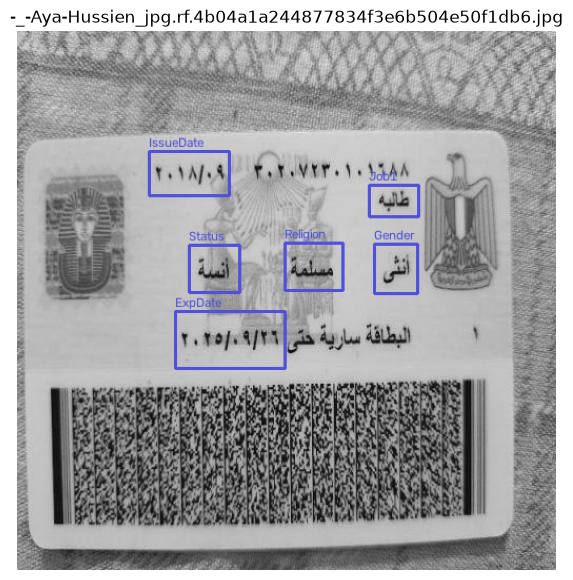

In [5]:
def yolo_to_xyxy(box, width: int, height: int, pad: float = 0.0):
    cls_id, xc, yc, bw, bh = box
    abs_w = bw * width
    abs_h = bh * height
    cx = xc * width
    cy = yc * height
    pad_x = abs_w * pad
    pad_y = abs_h * pad
    x1 = max(0, int(cx - abs_w / 2 - pad_x))
    y1 = max(0, int(cy - abs_h / 2 - pad_y))
    x2 = min(width, int(cx + abs_w / 2 + pad_x))
    y2 = min(height, int(cy + abs_h / 2 + pad_y))
    return int(cls_id), x1, y1, x2, y2


def read_yolo_label(path: Path):
    boxes = []
    if not path.exists():
        return boxes
    for line in path.read_text(encoding="utf-8").splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls_id, xc, yc, bw, bh = parts
        boxes.append((int(cls_id), float(xc), float(yc), float(bw), float(bh)))
    return boxes


sample_img = next((DATASET / "train" / "images").glob("*.jpg"))
sample_lbl = DATASET / "train" / "labels" / f"{sample_img.stem}.txt"
image = cv2.cvtColor(cv2.imread(str(sample_img)), cv2.COLOR_BGR2RGB)
h, w = image.shape[:2]
vis = image.copy()
for box in read_yolo_label(sample_lbl):
    cls_id, x1, y1, x2, y2 = yolo_to_xyxy(box, w, h)
    color = (0, 200, 0) if names[cls_id] == "ID" else (80, 80, 220)
    cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
    cv2.putText(vis, names[cls_id], (x1, max(12, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

plt.figure(figsize=(7, 7))
plt.imshow(vis)
plt.axis("off")
plt.title(sample_img.name)
plt.show()

## Train YOLO

Nano model, 50 epochs, 640px. Lower `BATCH` if you run out of VRAM. Weights land in `runs/nid_localize/weights/best.pt`.

Cosine LR (`cos_lr=True`): warmup, then LR follows a cosine from `LR0` down to `LR0 * LRF`. Change `LR0` in the config cell. `optimizer` is `AdamW`, not `auto`, because `auto` ignores `lr0`. Early stopping is still `patience=20`.


In [7]:
if RUN_TRAIN:
    model = YOLO(MODEL_NAME)
    results = model.train(
        data=str(DATA_YAML),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        project=str(RUNS_DIR),
        name="nid_localize",
        exist_ok=True,
        plots=True,
        patience=20,
        device=DEVICE,
        workers=0,
        cos_lr=True,
        lr0=LR0,
        lrf=LRF,
        optimizer=OPTIMIZER,
    )
    print(results.save_dir)
else:
    print("Skipped training (RUN_TRAIN=False)")

Ultralytics 8.4.126  Python-3.12.6 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=c:\Users\LOQ\Desktop\I_School\ID-OCR\nid_localization.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0

## Validate


In [ ]:
weights = RUNS_DIR / "nid_localize" / "weights" / "best.pt"
if not weights.exists():
    raise FileNotFoundError(f"No weights at {weights}. Train first or set RUN_TRAIN=True.")

trained = YOLO(str(weights))
metrics = trained.val(data=str(DATA_YAML), imgsz=IMGSZ, split="test")
print("mAP50:", round(float(metrics.box.map50), 4))
print("mAP50-95:", round(float(metrics.box.map), 4))
id_idx = NAME_TO_ID["ID"]
maps = getattr(metrics.box, "maps", None)
if maps is not None and len(maps) > id_idx:
    print("ID mAP50-95:", round(float(maps[id_idx]), 4))

## Infer and crop `ID` detections

Crops from the trained model go to `yolo+ocr/crops/pred/ID/`. Run digit OCR with [`digit_nid.py`](yolo+ocr/digit_nid.py) or the full pipeline.


In [ ]:
def crop_predictions(source_dir: Path, dest_dir: Path) -> int:
    dest_dir.mkdir(parents=True, exist_ok=True)
    saved = 0
    results = trained.predict(
        source=str(source_dir),
        imgsz=IMGSZ,
        conf=CONF,
        classes=CROP_CLASS_IDS,
        stream=True,
        verbose=False,
    )
    for result in results:
        image = result.orig_img
        if result.boxes is None or len(result.boxes) == 0:
            continue
        stem = Path(result.path).stem
        xyxy = result.boxes.xyxy.cpu().numpy()
        h, w = image.shape[:2]
        kept = []
        for box in xyxy:
            x1, y1, x2, y2 = box.tolist()
            bw, bh = x2 - x1, y2 - y1
            x1 = max(0, int(x1 - bw * CROP_PAD))
            y1 = max(0, int(y1 - bh * CROP_PAD))
            x2 = min(w, int(x2 + bw * CROP_PAD))
            y2 = min(h, int(y2 + bh * CROP_PAD))
            crop = image[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            kept.append(crop)
        for i, crop in enumerate(kept):
            suffix = "" if len(kept) == 1 else f"_{i}"
            cv2.imwrite(str(dest_dir / f"{stem}{suffix}.jpg"), crop)
            saved += 1
    return saved


if RUN_INFER_CROPS:
    pred_dir = CROPS_DIR / "pred" / "ID"
    n = crop_predictions(DATASET / "test" / "images", pred_dir)
    print(f"Saved {n} predicted ID crops to {pred_dir}")
else:
    print("Skipped inference crops (RUN_INFER_CROPS=False)")

## Next: digit OCR

1. Train digit detector: [`train_nid_digits.ipynb`](train_nid_digits.ipynb) on `cro4.v1-8.yolov8`
2. Read crops: `python yolo+ocr/digit_nid.py --input yolo+ocr/crops/pred/ID --device 0`
3. Full cards: `python yolo+ocr/run_pipeline.py --source yolo+ocr/real-samples --device 0`
